In [1]:
# Setup: Install evolve framework and configure path
import os
import subprocess
import sys

# Install in editable mode
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "-e", "/Users/lucasflores/evolve-framework"]
)

# Add to path
parent_dir = os.path.abspath("/Users/lucasflores/evolve-framework")
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print("✓ Package installed successfully!")
print("✓ Python path configured")

# Test import
try:
    import evolve

    print(f"✓ evolve module ready: {evolve.__version__}")
except ImportError as e:
    print(f"✗ Failed to import evolve: {e}")

✓ Package installed successfully!
✓ Python path configured
✓ evolve module ready: 0.1.0


# Tutorial 2: SequenceGenome for Genetic Programming

**Learning Objectives:**
- Understand variable-length sequence representations for evolving *structure*
- Learn genetic programming concepts through symbolic regression
- Visualize expression trees and understand subtree crossover
- Apply bloat control to keep evolved expressions interpretable
- Use island models for diverse expression discovery

**Prerequisites:**
- Tutorial 01 (VectorGenome basics)
- Basic Python and NumPy

**ML Practitioner Connection:**
- In deep learning, you choose architectures (layers, connections)
- Genetic programming *evolves* the architecture itself
- Think of it as automated feature engineering + model structure discovery

## Part 1: Setup and Imports

In [21]:
# Core Python
import os
import sys
import tempfile
import warnings
from dataclasses import dataclass
from random import Random

import matplotlib.pyplot as plt

# Numerical computing
import numpy as np

# Add project root to path for imports
sys.path.insert(0, "../..")

# Evolve framework

# Tutorial utilities
from docs.tutorials.utils.tutorial_utils import (
    # Island model
    check_gpu_available,
    # Dataclasses
    generate_polynomial_data,
    print_glossary_table,
    render_mermaid,
)

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

print("✅ All imports successful!")
print(f"NumPy version: {np.__version__}")

✅ All imports successful!
NumPy version: 2.4.2


## Part 2: EA Primer - Variable-Length Representations (FR-012)

### From Fixed to Variable Structure

In Tutorial 01, we evolved **fixed-length vectors** - like tuning hyperparameters.

Now we evolve **variable-length sequences** - like discovering model architecture.

| Aspect | VectorGenome | SequenceGenome |
|--------|--------------|----------------|
| **Length** | Fixed | Variable |
| **ML Analogy** | Tuning hyperparameters | Neural architecture search |
| **Search Space** | Continuous | Discrete + structural |
| **Key Challenge** | Local optima | Bloat (runaway growth) |

### Genetic Programming: Evolving Programs

Genetic Programming (GP) evolves **programs** or **mathematical expressions**:

- **Genome**: A tree-structured expression (e.g., `(+ (* x x) (* 3 x) 5)`)
- **Phenotype**: The executable function it represents: f(x) = x² + 3x + 5
- **Fitness**: How well the expression fits the data (like loss in ML)

This is **automated feature engineering** - the algorithm discovers mathematical relationships!

In [12]:
# Key terminology for genetic programming
gp_terms = [
    "genome",
    "phenotype",
    "fitness",
    "mutation",
    "crossover",
    "selection",
    "population",
    "generation",
]

print("🧬 Genetic Programming Terminology\n")
print_glossary_table()  # Prints all terms from glossary

print("\n📊 Additional GP-Specific Terms:")
print("-" * 50)
print("Terminal   | Leaf node (variable or constant) - like input features")
print("Function   | Internal node (+, -, *, sin) - like activation functions")
print("Subtree    | Any node and its descendants - like a layer block")
print("Bloat      | Runaway tree growth - like overfitting in structure")
print("Parsimony  | Penalty for complexity - like L1 regularization")

🧬 Genetic Programming Terminology



EA Term,ML Analogy,Biology Origin,Explanation
Genome,Model weights,DNA,"Complete parameter encoding of a solution. Like neural network weights, the genome contains all the information needed to produce behavior."
Phenotype,Model behavior/predictions,Organism,"The decoded/evaluated form of a genome. The phenotype is what gets evaluated for fitness, similar to how model predictions are what get scored."
Fitness,-Loss (negative loss),Survival/reproductive success,"Quality measure we maximize. Higher fitness = better solution. For minimization problems, fitness = -objective_value."
Population,Ensemble of models,Species,Collection of candidate solutions maintained simultaneously. Like maintaining multiple model instances to explore solution space.
Generation,Epoch/iteration,Lifespan,One full cycle of selection and variation. Each generation produces a new population from the previous one.
Selection,Sampling by quality,Natural selection,Choosing individuals to be parents based on fitness. Higher fitness = higher probability of being selected. Like importance sampling.
Crossover,Weight interpolation,Sexual reproduction,Combining information from two parents to create offspring. Similar to model interpolation or mixing weight matrices.
Mutation,Gradient noise / perturbation,Random mutation,"Small random changes to a genome. Enables exploration of nearby solutions, similar to adding noise to gradients or weights."
Elitism,Best checkpoint preservation,N/A (artificial),"Preserving the top performers unchanged into the next generation. Guarantees best fitness never decreases, like saving best model checkpoint."
Diversity,Ensemble variance,Biodiversity,Spread of population in solution space. High diversity = exploring widely; low diversity = converging. Prevents premature convergence.



📊 Additional GP-Specific Terms:
--------------------------------------------------
Terminal   | Leaf node (variable or constant) - like input features
Function   | Internal node (+, -, *, sin) - like activation functions
Subtree    | Any node and its descendants - like a layer block
Bloat      | Runaway tree growth - like overfitting in structure
Parsimony  | Penalty for complexity - like L1 regularization


## Part 3: Mermaid Diagrams - Expression Trees (FR-014)

📊 Expression Tree Structure
Blue = Function nodes (operators)
Green = Terminal nodes (variables/constants)


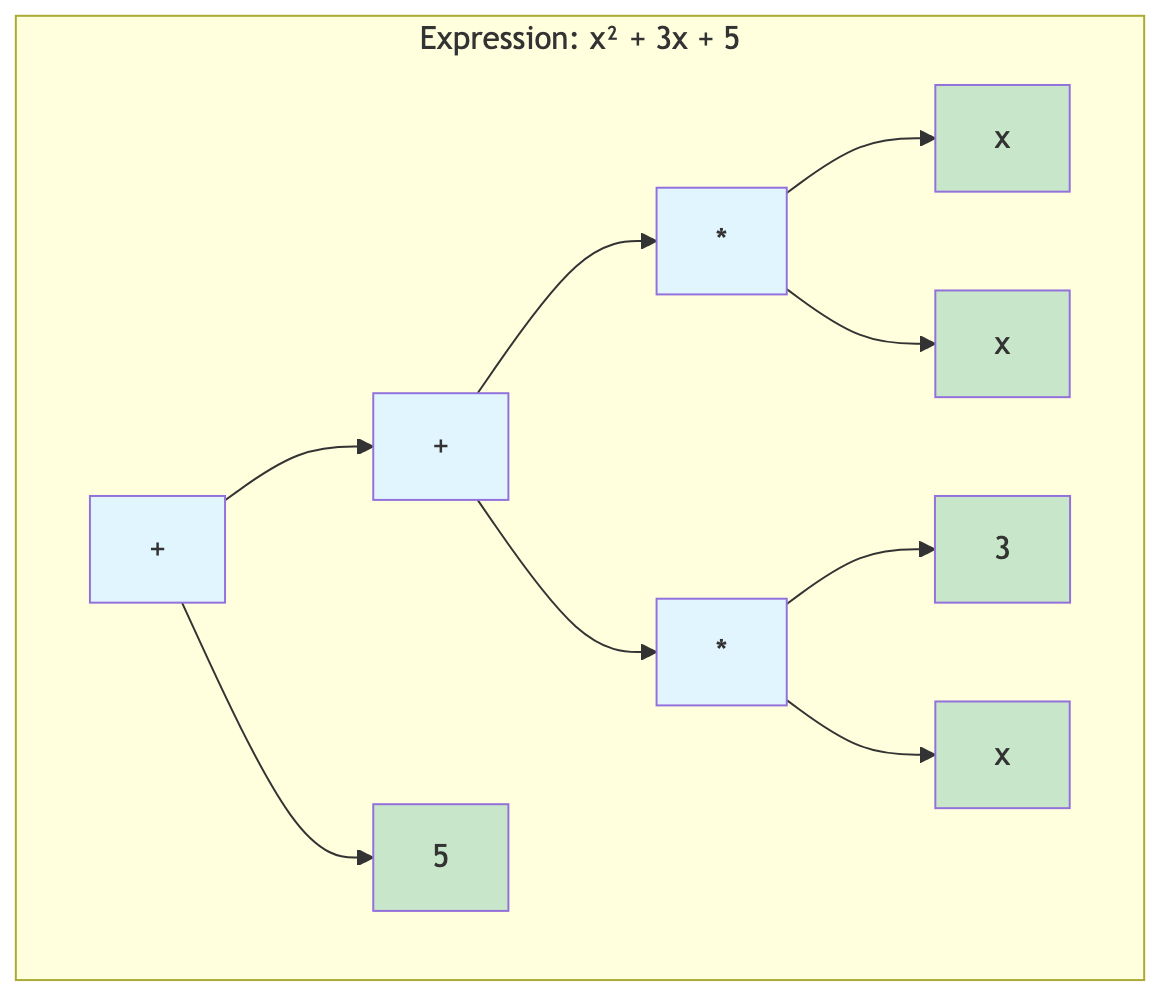

In [22]:
# Diagram 1: Expression Tree Structure
EXPRESSION_TREE_DIAGRAM = """
graph TD
    subgraph "Expression: x² + 3x + 5"
        A["+"] --> B["+"]
        A --> C["5"]
        B --> D["*"]
        B --> E["*"]
        D --> F["x"]
        D --> G["x"]
        E --> H["3"]
        E --> I["x"]
    end
    
    style A fill:#e1f5fe
    style B fill:#e1f5fe
    style D fill:#e1f5fe
    style E fill:#e1f5fe
    style C fill:#c8e6c9
    style F fill:#c8e6c9
    style G fill:#c8e6c9
    style H fill:#c8e6c9
    style I fill:#c8e6c9
"""

print("📊 Expression Tree Structure")
print("Blue = Function nodes (operators)")
print("Green = Terminal nodes (variables/constants)")
try:
    render_mermaid(EXPRESSION_TREE_DIAGRAM)
except Exception as e:
    print(f"Mermaid rendering not available: {e}")
    print("\nTree representation: (+ (+ (* x x) (* 3 x)) 5)")


📊 Subtree Crossover
Swaps entire subtrees between parents (not just single values!)


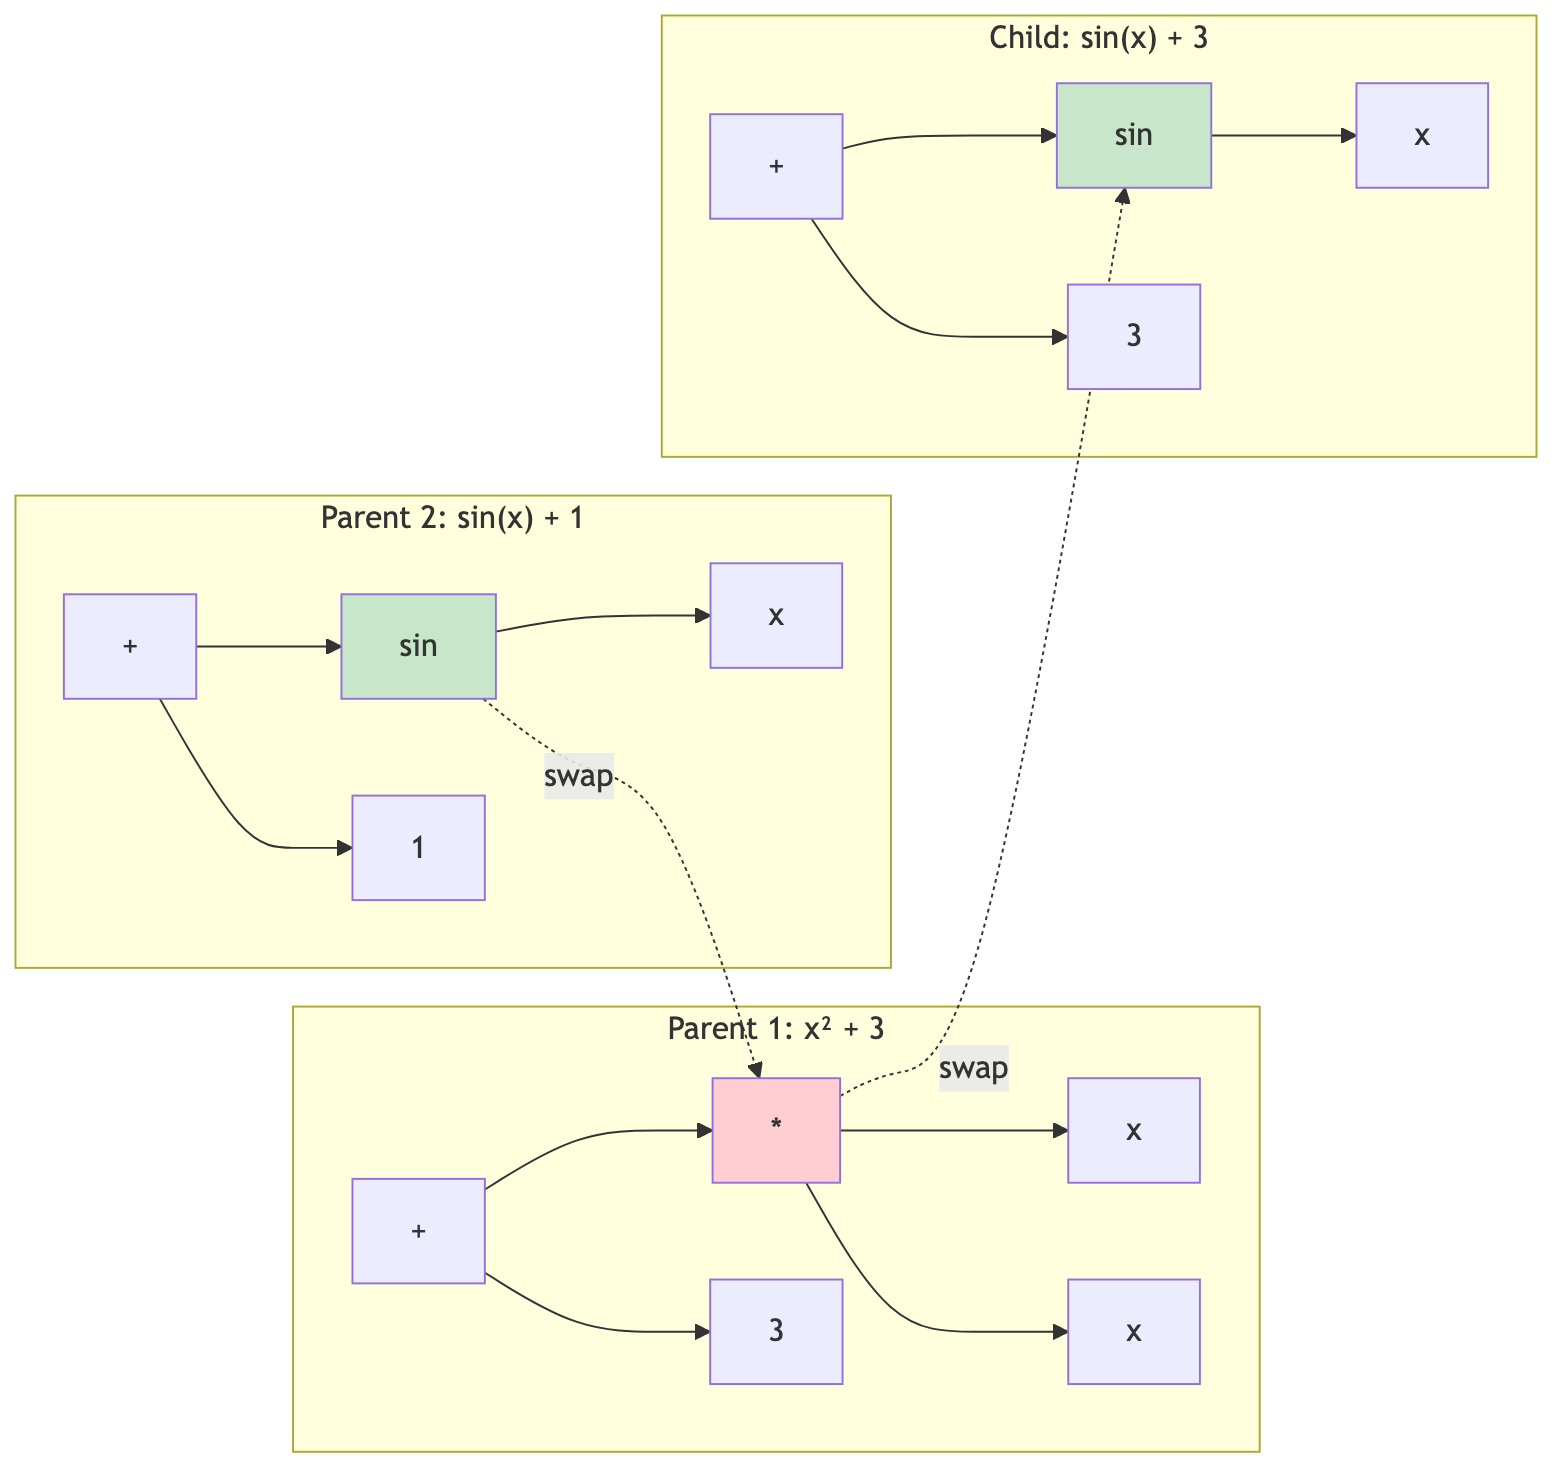

In [23]:
# Diagram 2: Subtree Crossover
SUBTREE_CROSSOVER_DIAGRAM = """
graph LR
    subgraph Parent1["Parent 1: x² + 3"]
        P1A["+"] --> P1B["*"]
        P1A --> P1C["3"]
        P1B --> P1D["x"]
        P1B --> P1E["x"]
    end
    
    subgraph Parent2["Parent 2: sin(x) + 1"]
        P2A["+"] --> P2B["sin"]
        P2A --> P2C["1"]
        P2B --> P2D["x"]
    end
    
    subgraph Child["Child: sin(x) + 3"]
        CA["+"] --> CB["sin"]
        CA --> CC["3"]
        CB --> CD["x"]
    end
    
    P1B -.->|"swap"| CB
    P2B -.->|"swap"| P1B
    
    style P1B fill:#ffcdd2
    style P2B fill:#c8e6c9
    style CB fill:#c8e6c9
"""

print("\n📊 Subtree Crossover")
print("Swaps entire subtrees between parents (not just single values!)")
try:
    render_mermaid(SUBTREE_CROSSOVER_DIAGRAM)
except Exception:
    print("\nSubtree crossover: swap (* x x) with (sin x)")


📊 Genetic Programming Pipeline


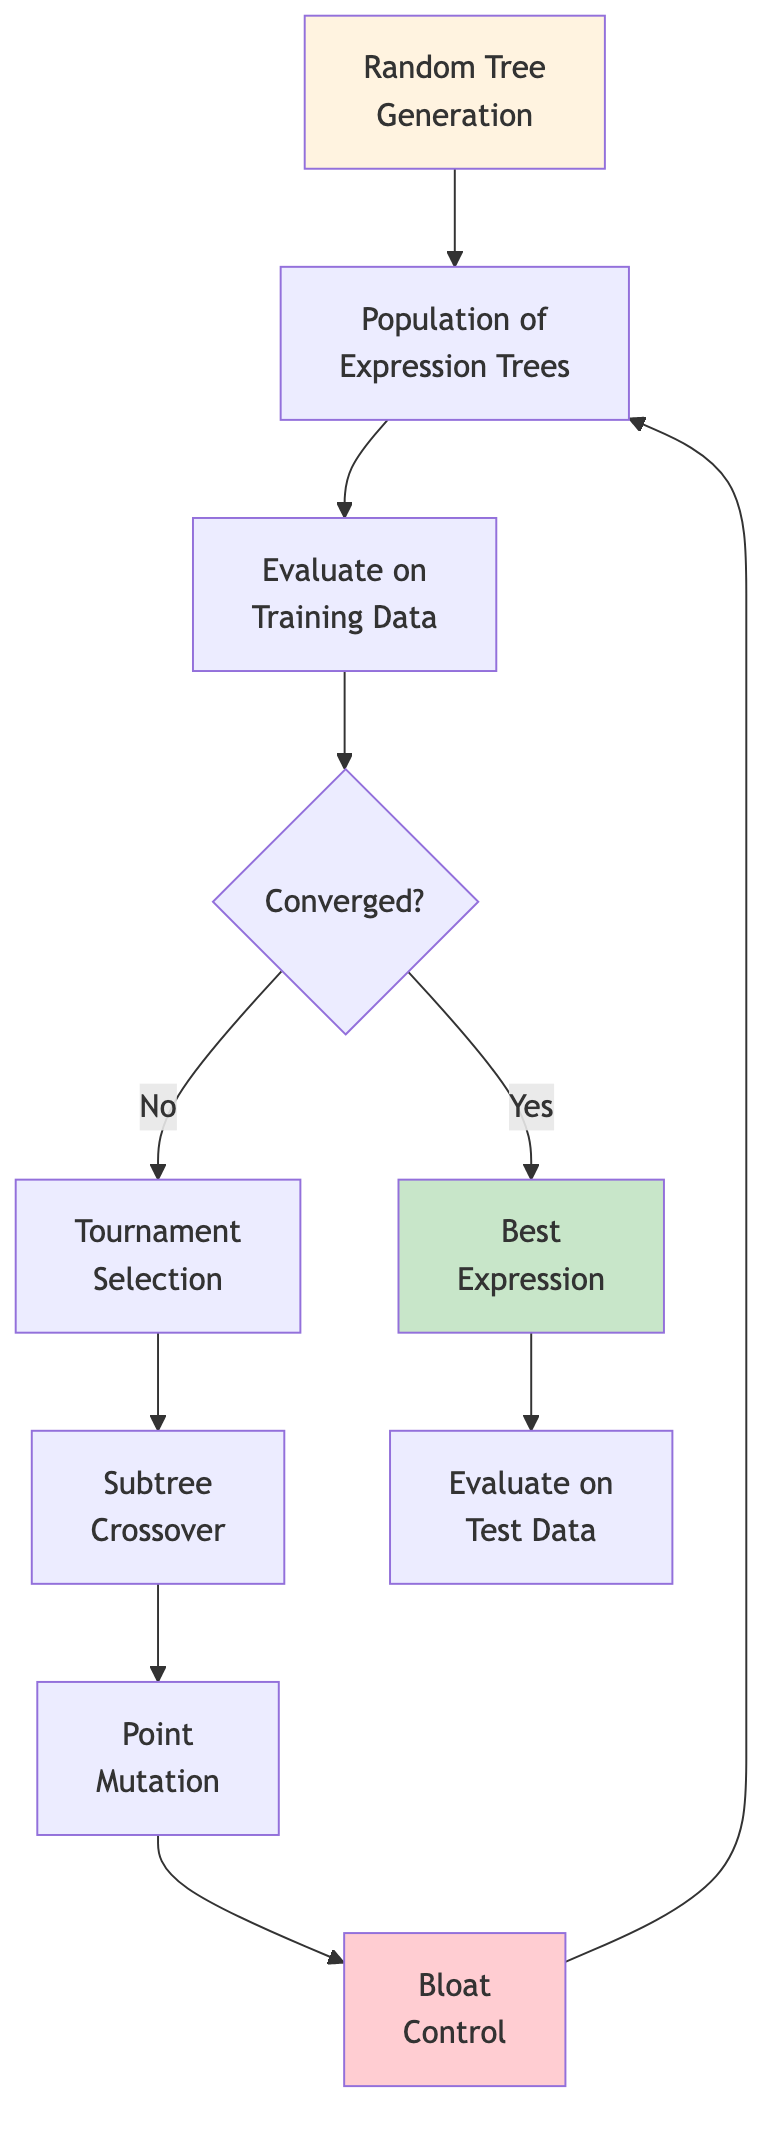

In [24]:
# Diagram 3: GP Evolution Pipeline
GP_PIPELINE_DIAGRAM = """
graph TD
    A["Random Tree\nGeneration"] --> B["Population of\nExpression Trees"]
    B --> C["Evaluate on\nTraining Data"]
    C --> D{"Converged?"}
    D -->|No| E["Tournament\nSelection"]
    E --> F["Subtree\nCrossover"]
    F --> G["Point\nMutation"]
    G --> H["Bloat\nControl"]
    H --> B
    D -->|Yes| I["Best\nExpression"]
    I --> J["Evaluate on\nTest Data"]
    
    style A fill:#fff3e0
    style I fill:#c8e6c9
    style H fill:#ffcdd2
"""

print("\n📊 Genetic Programming Pipeline")
try:
    render_mermaid(GP_PIPELINE_DIAGRAM)
except Exception:
    print("GP Pipeline: Generate → Evaluate → Select → Crossover → Mutate → Control Bloat → Repeat")

## Part 4: Problem Setup - Symbolic Regression

**Goal**: Discover the mathematical relationship between inputs and outputs.

This is like fitting a neural network, but instead of learning weights, we evolve the *formula itself*!

### Advantages over Neural Networks:
- **Interpretable**: You get an actual equation
- **Generalizable**: Simpler expressions often generalize better
- **No architecture choice**: The algorithm finds the structure

🎯 Target: Rediscover the polynomial relationship
   True expression: 0.72*x^2 + -0.12*x + 0.55
   Training samples: 80
   Test samples: 20


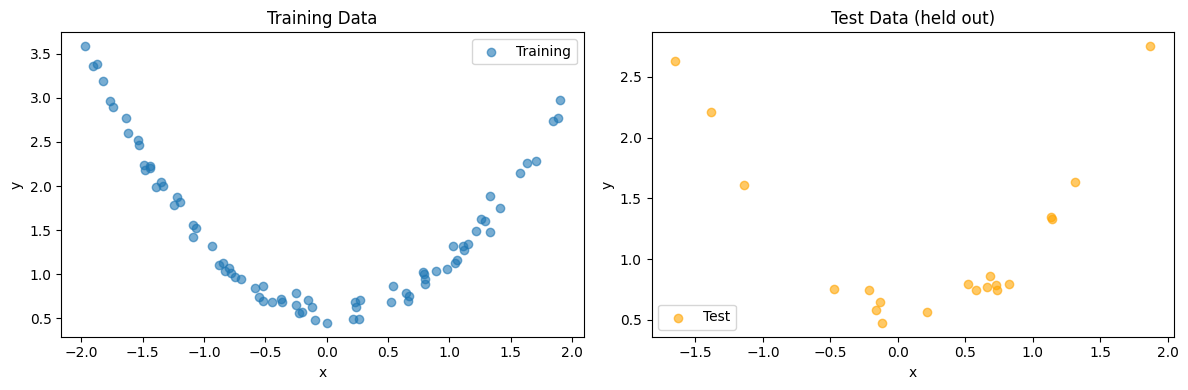

In [13]:
# Generate synthetic data from a known polynomial
# We'll try to rediscover this relationship through evolution

data = generate_polynomial_data(
    degree=2, n_samples=100, noise_level=0.1, seed=42, test_fraction=0.2
)

print("🎯 Target: Rediscover the polynomial relationship")
print(f"   True expression: {data.true_expression}")
print(f"   Training samples: {len(data.X_train)}")
print(f"   Test samples: {len(data.X_test)}")

# Visualize the data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training data
axes[0].scatter(data.X_train, data.y_train, alpha=0.6, label="Training")
x_line = np.linspace(data.X_train.min(), data.X_train.max(), 100)
# Plot true function (without noise)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Training Data")
axes[0].legend()

# Test data
axes[1].scatter(data.X_test, data.y_test, alpha=0.6, color="orange", label="Test")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Test Data (held out)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Part 5: Expression Tree Implementation (FR-032)

We'll build a simple expression tree system that works with `SequenceGenome`.

**Representation**: Prefix notation sequence (like Lisp)
- `(+ x 1)` → `['+', 'x', '1']`
- `(* x x)` → `['*', 'x', 'x']`
- `(+ (* x x) 1)` → `['+', '*', 'x', 'x', '1']`

In [25]:
@dataclass
class ExpressionTree:
    """A tree node for mathematical expressions."""

    value: str
    children: list["ExpressionTree"] = None

    def __post_init__(self):
        if self.children is None:
            self.children = []

    def is_terminal(self) -> bool:
        """Check if this is a leaf node."""
        return len(self.children) == 0

    def depth(self) -> int:
        """Calculate tree depth."""
        if self.is_terminal():
            return 1
        return 1 + max(child.depth() for child in self.children)

    def size(self) -> int:
        """Count total nodes."""
        if self.is_terminal():
            return 1
        return 1 + sum(child.size() for child in self.children)

    def to_string(self) -> str:
        """Convert to human-readable infix notation."""
        if self.is_terminal():
            return self.value
        if len(self.children) == 1:
            # Unary operator (like sin, cos)
            return f"{self.value}({self.children[0].to_string()})"
        # Binary operator
        left = self.children[0].to_string()
        right = self.children[1].to_string()
        return f"({left} {self.value} {right})"

    def evaluate(self, x: float) -> float:
        """Evaluate the expression for a given x value."""
        if self.is_terminal():
            if self.value == "x":
                return x
            try:
                return float(self.value)
            except ValueError:
                return 0.0

        # Evaluate children
        child_vals = [child.evaluate(x) for child in self.children]

        # Apply operator
        ops = {
            "+": lambda a, b: a + b,
            "-": lambda a, b: a - b,
            "*": lambda a, b: a * b,
            "/": lambda a, b: a / b if abs(b) > 1e-10 else 1.0,
            "sin": lambda a: np.sin(a),
            "cos": lambda a: np.cos(a),
            "exp": lambda a: np.clip(np.exp(np.clip(a, -10, 10)), -1e10, 1e10),
            "sqrt": lambda a: np.sqrt(abs(a)),
        }

        try:
            if self.value in ["sin", "cos", "exp", "sqrt"]:
                return ops[self.value](child_vals[0])
            else:
                return ops[self.value](child_vals[0], child_vals[1])
        except (OverflowError, ValueError):
            return float("inf")


# Define our function and terminal sets
FUNCTIONS = ["+", "-", "*", "/"]  # Binary operators
UNARY_FUNCTIONS = ["sin", "cos"]  # Unary operators
TERMINALS = ["x", "1", "2", "3", "0.5"]  # Variables and constants

print("✅ ExpressionTree class defined")
print(f"   Functions: {FUNCTIONS}")
print(f"   Unary: {UNARY_FUNCTIONS}")
print(f"   Terminals: {TERMINALS}")

✅ ExpressionTree class defined
   Functions: ['+', '-', '*', '/']
   Unary: ['sin', 'cos']
   Terminals: ['x', '1', '2', '3', '0.5']


In [26]:
def random_tree(rng: Random, max_depth: int = 4, current_depth: int = 0) -> ExpressionTree:
    """
    Generate a random expression tree.

    Uses the 'grow' method: probabilistically choose between
    functions and terminals at each node.
    """
    # Force terminal at max depth
    if current_depth >= max_depth:
        return ExpressionTree(value=rng.choice(TERMINALS))

    # Probability of choosing a function decreases with depth
    func_prob = 0.7 * (1 - current_depth / max_depth)

    if rng.random() < func_prob:
        # Choose a function
        if rng.random() < 0.8:  # 80% binary, 20% unary
            op = rng.choice(FUNCTIONS)
            left = random_tree(rng, max_depth, current_depth + 1)
            right = random_tree(rng, max_depth, current_depth + 1)
            return ExpressionTree(value=op, children=[left, right])
        else:
            op = rng.choice(UNARY_FUNCTIONS)
            child = random_tree(rng, max_depth, current_depth + 1)
            return ExpressionTree(value=op, children=[child])
    else:
        # Choose a terminal
        return ExpressionTree(value=rng.choice(TERMINALS))


# Generate and display some random trees
rng = Random(42)
print("🌳 Random Expression Trees:")
print("=" * 50)
for i in range(5):
    tree = random_tree(rng, max_depth=3)
    print(f"Tree {i + 1}: {tree.to_string()}")
    print(f"         Depth: {tree.depth()}, Size: {tree.size()} nodes")

🌳 Random Expression Trees:
Tree 1: ((0.5 + (x + 1)) * (0.5 - 3))
         Depth: 4, Size: 9 nodes
Tree 2: sin(1)
         Depth: 2, Size: 2 nodes
Tree 3: (((0.5 * 2) + 3) - 3)
         Depth: 4, Size: 7 nodes
Tree 4: (x * (1 * 3))
         Depth: 3, Size: 5 nodes
Tree 5: ((x * 1) * 1)
         Depth: 3, Size: 5 nodes


## Part 6: Tree Visualization (FR-032)

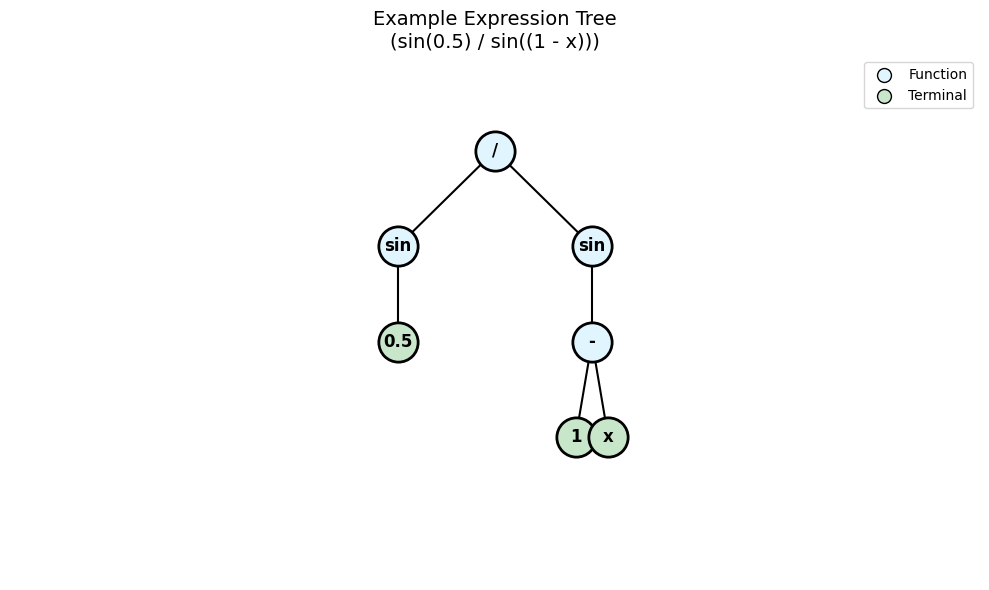


📊 Evaluation at x = [0. 1. 2.]:
   f(0.0) = 0.5697
   f(1.0) = 1.0000
   f(2.0) = -0.5697


In [14]:
def plot_expression_tree(tree: ExpressionTree, title: str = "Expression Tree"):
    """
    Visualize an expression tree using matplotlib.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Calculate positions using a simple recursive layout
    positions = {}
    labels = {}
    edges = []
    node_id = [0]  # Mutable counter

    def layout_tree(node, x, y, dx, node_num):
        current_id = node_num[0]
        positions[current_id] = (x, y)
        labels[current_id] = node.value
        node_num[0] += 1

        if node.children:
            n_children = len(node.children)
            child_dx = dx / (n_children + 1)
            for i, child in enumerate(node.children):
                child_x = x + (i - (n_children - 1) / 2) * dx * 0.5
                child_id = layout_tree(child, child_x, y - 1, child_dx, node_num)
                edges.append((current_id, child_id))

        return current_id

    layout_tree(tree, 0, 0, 4, node_id)

    # Draw edges
    for parent, child in edges:
        x1, y1 = positions[parent]
        x2, y2 = positions[child]
        ax.plot([x1, x2], [y1, y2], "k-", linewidth=1.5, zorder=1)

    # Draw nodes
    for node_id, (x, y) in positions.items():
        label = labels[node_id]
        is_terminal = label in TERMINALS
        color = "#c8e6c9" if is_terminal else "#e1f5fe"
        ax.scatter(x, y, s=800, c=color, edgecolors="black", linewidth=2, zorder=2)
        ax.text(x, y, label, ha="center", va="center", fontsize=12, fontweight="bold", zorder=3)

    ax.set_xlim(-5, 5)
    ax.set_ylim(-tree.depth() - 0.5, 1)
    ax.axis("off")
    ax.set_title(f"{title}\n{tree.to_string()}", fontsize=14)

    # Legend
    ax.scatter([], [], c="#e1f5fe", edgecolors="black", s=100, label="Function")
    ax.scatter([], [], c="#c8e6c9", edgecolors="black", s=100, label="Terminal")
    ax.legend(loc="upper right")

    plt.tight_layout()
    return fig


# Visualize a tree
demo_tree = random_tree(Random(123), max_depth=3)
fig = plot_expression_tree(demo_tree, "Example Expression Tree")
plt.show()

# Show evaluation
test_x = np.array([0.0, 1.0, 2.0])
print(f"\n📊 Evaluation at x = {test_x}:")
for x_val in test_x:
    y_val = demo_tree.evaluate(x_val)
    print(f"   f({x_val}) = {y_val:.4f}")

## Part 7: Subtree Crossover Visualization (FR-032)

Unlike vector crossover (which swaps individual values), subtree crossover swaps *entire branches*.

This is powerful because it preserves meaningful "building blocks" in the expression.

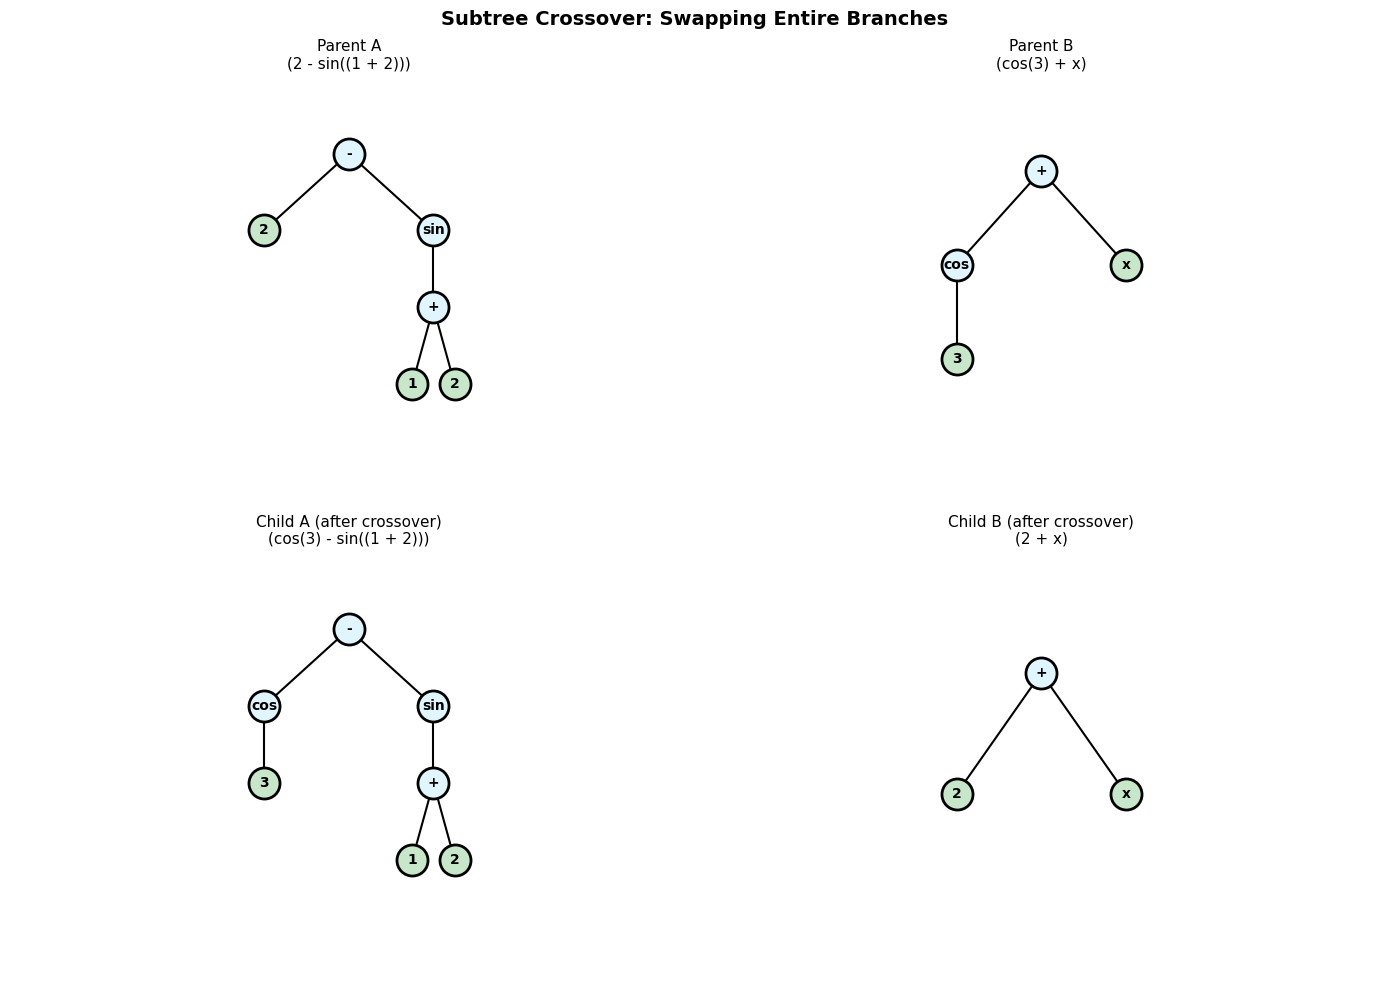


🔀 Subtree Crossover vs Vector Crossover:
   Vector: Swap individual positions (like swapping single genes)
   Subtree: Swap entire subtrees (like swapping functional modules)


In [15]:
def get_all_nodes(tree: ExpressionTree) -> list[tuple[ExpressionTree, ExpressionTree, int]]:
    """
    Get all nodes with their parent and child index.
    Returns list of (node, parent, child_index) tuples.
    """
    nodes = [(tree, None, -1)]  # Root has no parent

    def collect(node, parent, idx):
        for i, child in enumerate(node.children):
            nodes.append((child, node, i))
            collect(child, node, i)

    collect(tree, None, -1)
    return nodes


def deep_copy_tree(tree: ExpressionTree) -> ExpressionTree:
    """Create a deep copy of a tree."""
    return ExpressionTree(value=tree.value, children=[deep_copy_tree(c) for c in tree.children])


def subtree_crossover(
    parent1: ExpressionTree, parent2: ExpressionTree, rng: Random
) -> tuple[ExpressionTree, ExpressionTree]:
    """
    Perform subtree crossover between two expression trees.

    1. Select random crossover points in each parent
    2. Swap the subtrees at those points
    """
    # Deep copy parents
    child1 = deep_copy_tree(parent1)
    child2 = deep_copy_tree(parent2)

    # Get all nodes (excluding root for simplicity)
    nodes1 = get_all_nodes(child1)[1:]  # Skip root
    nodes2 = get_all_nodes(child2)[1:]

    if not nodes1 or not nodes2:
        return child1, child2

    # Select crossover points
    node1, parent1_node, idx1 = rng.choice(nodes1)
    node2, parent2_node, idx2 = rng.choice(nodes2)

    # Swap subtrees
    parent1_node.children[idx1] = deep_copy_tree(node2)
    parent2_node.children[idx2] = deep_copy_tree(node1)

    return child1, child2


# Demonstrate subtree crossover
rng = Random(42)
parent_a = random_tree(Random(100), max_depth=3)
parent_b = random_tree(Random(200), max_depth=3)

child_a, child_b = subtree_crossover(parent_a, parent_b, rng)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


def plot_tree_in_ax(ax, tree, title):
    """Plot tree in a specific axis."""
    positions = {}
    labels = {}
    edges = []
    node_id = [0]

    def layout(node, x, y, dx, num):
        current = num[0]
        positions[current] = (x, y)
        labels[current] = node.value
        num[0] += 1
        if node.children:
            n = len(node.children)
            for i, child in enumerate(node.children):
                cx = x + (i - (n - 1) / 2) * dx * 0.5
                cid = layout(child, cx, y - 1, dx / 2, num)
                edges.append((current, cid))
        return current

    layout(tree, 0, 0, 3, node_id)

    for p, c in edges:
        ax.plot(
            [positions[p][0], positions[c][0]], [positions[p][1], positions[c][1]], "k-", lw=1.5
        )

    for nid, (x, y) in positions.items():
        label = labels[nid]
        color = "#c8e6c9" if label in TERMINALS else "#e1f5fe"
        ax.scatter(x, y, s=500, c=color, edgecolors="black", lw=2, zorder=2)
        ax.text(x, y, label, ha="center", va="center", fontsize=10, fontweight="bold")

    ax.set_title(f"{title}\n{tree.to_string()}", fontsize=11)
    ax.axis("off")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-tree.depth() - 0.5, 1)


plot_tree_in_ax(axes[0, 0], parent_a, "Parent A")
plot_tree_in_ax(axes[0, 1], parent_b, "Parent B")
plot_tree_in_ax(axes[1, 0], child_a, "Child A (after crossover)")
plot_tree_in_ax(axes[1, 1], child_b, "Child B (after crossover)")

plt.suptitle("Subtree Crossover: Swapping Entire Branches", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n🔀 Subtree Crossover vs Vector Crossover:")
print("   Vector: Swap individual positions (like swapping single genes)")
print("   Subtree: Swap entire subtrees (like swapping functional modules)")

## Part 8: Bloat Control (FR-033)

**Bloat** is when trees grow large without improving fitness - like overfitting in structure!

### Common Bloat Control Methods:

1. **Depth Limit**: Cap maximum tree depth
2. **Size Limit**: Cap total number of nodes  
3. **Parsimony Pressure**: Penalize complexity in fitness
4. **Operator Bias**: Prefer operators that reduce size

In [16]:
def evaluate_with_parsimony(
    tree: ExpressionTree, x_data: np.ndarray, y_data: np.ndarray, parsimony_coef: float = 0.001
) -> float:
    """
    Evaluate expression with parsimony pressure.

    fitness = MSE + parsimony_coef * tree_size

    Lower is better (we minimize this).
    """
    # Calculate predictions
    predictions = np.array([tree.evaluate(x) for x in x_data])

    # Handle invalid predictions
    if np.any(np.isnan(predictions)) or np.any(np.isinf(predictions)):
        return float("inf")

    # MSE
    mse = np.mean((predictions - y_data) ** 2)

    # Parsimony penalty
    complexity_penalty = parsimony_coef * tree.size()

    return mse + complexity_penalty


# Demonstrate parsimony effect
print("📊 Parsimony Pressure Effect:")
print("=" * 50)

# Create two trees with similar MSE but different complexity
simple_tree = ExpressionTree(
    "+", [ExpressionTree("*", [ExpressionTree("x"), ExpressionTree("x")]), ExpressionTree("x")]
)  # x² + x

complex_tree = ExpressionTree(
    "+",
    [
        ExpressionTree(
            "+",
            [
                ExpressionTree("*", [ExpressionTree("x"), ExpressionTree("x")]),
                ExpressionTree("*", [ExpressionTree("1"), ExpressionTree("0.5")]),
            ],
        ),
        ExpressionTree(
            "-",
            [
                ExpressionTree("x"),
                ExpressionTree("*", [ExpressionTree("1"), ExpressionTree("0.5")]),
            ],
        ),
    ],
)  # ((x² + 0.5) + (x - 0.5)) ≈ x² + x

print(f"\nSimple tree: {simple_tree.to_string()}")
print(f"   Size: {simple_tree.size()} nodes")

print(f"\nComplex tree: {complex_tree.to_string()}")
print(f"   Size: {complex_tree.size()} nodes")

# Compare fitness with different parsimony coefficients
test_x = np.linspace(-2, 2, 20)
test_y = test_x**2 + test_x  # True function

print("\nFitness Comparison:")
for coef in [0.0, 0.01, 0.1]:
    fit_simple = evaluate_with_parsimony(simple_tree, test_x, test_y, coef)
    fit_complex = evaluate_with_parsimony(complex_tree, test_x, test_y, coef)
    winner = "Simple" if fit_simple < fit_complex else "Complex"
    print(
        f"   Parsimony={coef:.2f}: Simple={fit_simple:.4f}, Complex={fit_complex:.4f} → {winner} wins"
    )

📊 Parsimony Pressure Effect:

Simple tree: ((x * x) + x)
   Size: 5 nodes

Complex tree: (((x * x) + (1 * 0.5)) + (x - (1 * 0.5)))
   Size: 13 nodes

Fitness Comparison:
   Parsimony=0.00: Simple=0.0000, Complex=0.0000 → Simple wins
   Parsimony=0.01: Simple=0.0500, Complex=0.1300 → Simple wins
   Parsimony=0.10: Simple=0.5000, Complex=1.3000 → Simple wins


In [17]:
# Depth limiting function
def enforce_depth_limit(tree: ExpressionTree, max_depth: int, rng: Random) -> ExpressionTree:
    """
    Truncate tree if it exceeds max depth.
    Replaces deep subtrees with random terminals.
    """

    def truncate(node, current_depth):
        if current_depth >= max_depth:
            # Replace with terminal
            return ExpressionTree(value=rng.choice(TERMINALS))

        if node.is_terminal():
            return ExpressionTree(value=node.value)

        # Recursively truncate children
        new_children = [truncate(c, current_depth + 1) for c in node.children]
        return ExpressionTree(value=node.value, children=new_children)

    return truncate(tree, 0)


# Demonstrate depth limiting
rng = Random(42)
deep_tree = random_tree(rng, max_depth=6)
limited_tree = enforce_depth_limit(deep_tree, max_depth=3, rng=rng)

print("🌳 Depth Limiting:")
print(f"   Original: depth={deep_tree.depth()}, size={deep_tree.size()}")
print(f"   Limited:  depth={limited_tree.depth()}, size={limited_tree.size()}")

🌳 Depth Limiting:
   Original: depth=5, size=9
   Limited:  depth=4, size=7


## Part 9: Running Evolution (FR-031)

Now let's put it all together and evolve symbolic expressions!

In [18]:
def point_mutation(tree: ExpressionTree, rng: Random, mutation_rate: float = 0.1) -> ExpressionTree:
    """
    Point mutation: randomly replace node values.
    """

    def mutate(node):
        if rng.random() < mutation_rate:
            if node.is_terminal():
                return ExpressionTree(value=rng.choice(TERMINALS))
            else:
                # Replace with same arity operator
                if len(node.children) == 1:
                    new_op = rng.choice(UNARY_FUNCTIONS)
                else:
                    new_op = rng.choice(FUNCTIONS)
                return ExpressionTree(value=new_op, children=[mutate(c) for c in node.children])
        else:
            if node.is_terminal():
                return ExpressionTree(value=node.value)
            else:
                return ExpressionTree(value=node.value, children=[mutate(c) for c in node.children])

    return mutate(tree)


def tournament_select(
    population: list[ExpressionTree], fitnesses: list[float], rng: Random, tournament_size: int = 3
) -> ExpressionTree:
    """
    Tournament selection: pick best from random subset.
    """
    indices = rng.sample(range(len(population)), min(tournament_size, len(population)))
    best_idx = min(indices, key=lambda i: fitnesses[i])
    return deep_copy_tree(population[best_idx])


class GPEvolver:
    """
    Simple genetic programming evolver for symbolic regression.
    """

    def __init__(
        self,
        pop_size: int = 100,
        max_generations: int = 50,
        max_depth: int = 5,
        tournament_size: int = 3,
        crossover_rate: float = 0.9,
        mutation_rate: float = 0.1,
        parsimony_coef: float = 0.001,
        elitism: int = 2,
        seed: int = 42,
    ):
        self.pop_size = pop_size
        self.max_generations = max_generations
        self.max_depth = max_depth
        self.tournament_size = tournament_size
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.parsimony_coef = parsimony_coef
        self.elitism = elitism
        self.rng = Random(seed)

        self.history = {"best_fitness": [], "avg_fitness": [], "avg_size": []}

    def evolve(self, x_train: np.ndarray, y_train: np.ndarray) -> ExpressionTree:
        """
        Run genetic programming evolution.
        """
        # Initialize population
        population = [random_tree(self.rng, max_depth=self.max_depth) for _ in range(self.pop_size)]

        best_ever = None
        best_fitness = float("inf")

        for gen in range(self.max_generations):
            # Evaluate
            fitnesses = [
                evaluate_with_parsimony(ind, x_train, y_train, self.parsimony_coef)
                for ind in population
            ]

            # Track statistics
            gen_best_idx = np.argmin(fitnesses)
            gen_best_fitness = fitnesses[gen_best_idx]
            avg_fitness = np.mean([f for f in fitnesses if f < float("inf")])
            avg_size = np.mean([ind.size() for ind in population])

            self.history["best_fitness"].append(gen_best_fitness)
            self.history["avg_fitness"].append(avg_fitness)
            self.history["avg_size"].append(avg_size)

            # Update best ever
            if gen_best_fitness < best_fitness:
                best_fitness = gen_best_fitness
                best_ever = deep_copy_tree(population[gen_best_idx])

            # Progress report
            if gen % 10 == 0 or gen == self.max_generations - 1:
                print(
                    f"Gen {gen:3d}: Best={gen_best_fitness:.6f}, Avg={avg_fitness:.4f}, AvgSize={avg_size:.1f}"
                )

            # Create next generation
            new_population = []

            # Elitism: keep best individuals
            elite_indices = np.argsort(fitnesses)[: self.elitism]
            for idx in elite_indices:
                new_population.append(deep_copy_tree(population[idx]))

            # Fill rest with offspring
            while len(new_population) < self.pop_size:
                parent1 = tournament_select(population, fitnesses, self.rng, self.tournament_size)
                parent2 = tournament_select(population, fitnesses, self.rng, self.tournament_size)

                # Crossover
                if self.rng.random() < self.crossover_rate:
                    child1, child2 = subtree_crossover(parent1, parent2, self.rng)
                else:
                    child1, child2 = deep_copy_tree(parent1), deep_copy_tree(parent2)

                # Mutation
                child1 = point_mutation(child1, self.rng, self.mutation_rate)
                child2 = point_mutation(child2, self.rng, self.mutation_rate)

                # Depth limiting
                child1 = enforce_depth_limit(child1, self.max_depth, self.rng)
                child2 = enforce_depth_limit(child2, self.max_depth, self.rng)

                new_population.extend([child1, child2])

            population = new_population[: self.pop_size]

        return best_ever


print("✅ GPEvolver class defined")
print("   Ready to evolve symbolic expressions!")

✅ GPEvolver class defined
   Ready to evolve symbolic expressions!


In [19]:
# Run evolution on our polynomial data
print("🧬 Evolving symbolic regression...")
print(f"   Target: {data.true_expression}")
print("=" * 50)

evolver = GPEvolver(
    pop_size=200,
    max_generations=50,
    max_depth=5,
    tournament_size=5,
    crossover_rate=0.9,
    mutation_rate=0.1,
    parsimony_coef=0.001,
    elitism=5,
    seed=42,
)

best_tree = evolver.evolve(data.X_train.flatten(), data.y_train)

print("\n" + "=" * 50)
print(f"🏆 Best expression found: {best_tree.to_string()}")
print(f"   Tree size: {best_tree.size()} nodes")
print(f"   Tree depth: {best_tree.depth()}")

🧬 Evolving symbolic regression...
   Target: 0.72*x^2 + -0.12*x + 0.55
Gen   0: Best=0.682211, Avg=242.3552, AvgSize=5.1
Gen  10: Best=0.155437, Avg=17.0837, AvgSize=3.6
Gen  20: Best=0.155437, Avg=2.7462, AvgSize=3.0
Gen  30: Best=0.155437, Avg=1.9758, AvgSize=3.0
Gen  40: Best=0.155437, Avg=1.1582, AvgSize=3.0
Gen  49: Best=0.155437, Avg=1.4507, AvgSize=3.0

🏆 Best expression found: (x * x)
   Tree size: 3 nodes
   Tree depth: 2


## Part 10: Convergence Visualization (FR-015)

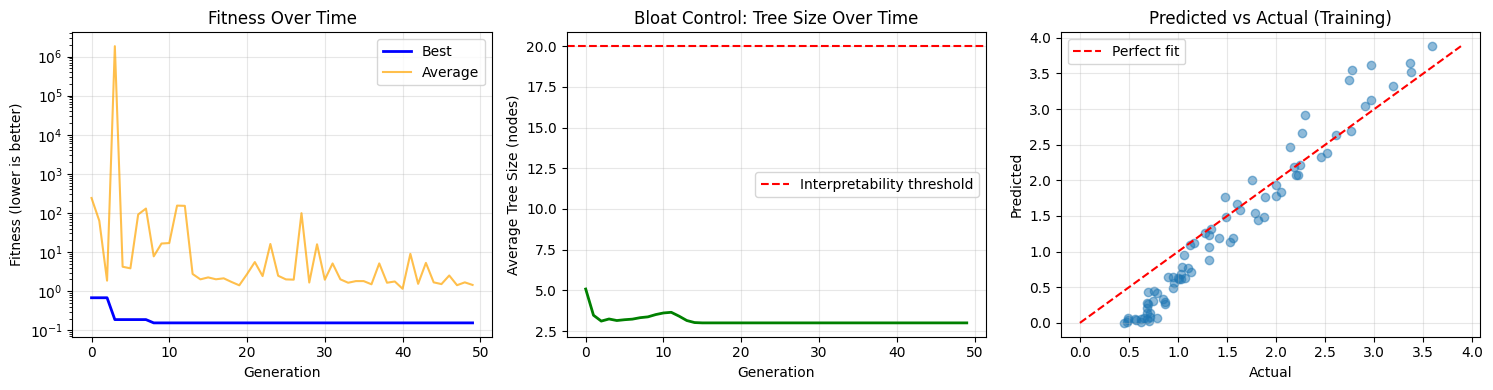


📊 Training R² score: 0.7755


In [20]:
# Plot evolution progress
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

generations = range(len(evolver.history["best_fitness"]))

# Fitness over time
axes[0].plot(generations, evolver.history["best_fitness"], "b-", label="Best", linewidth=2)
axes[0].plot(generations, evolver.history["avg_fitness"], "orange", label="Average", alpha=0.7)
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Fitness (lower is better)")
axes[0].set_title("Fitness Over Time")
axes[0].legend()
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

# Tree size over time (bloat indicator)
axes[1].plot(generations, evolver.history["avg_size"], "green", linewidth=2)
axes[1].axhline(y=20, color="red", linestyle="--", label="Interpretability threshold")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Average Tree Size (nodes)")
axes[1].set_title("Bloat Control: Tree Size Over Time")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Predicted vs actual
predictions = np.array([best_tree.evaluate(x) for x in data.X_train.flatten()])
axes[2].scatter(data.y_train, predictions, alpha=0.5)
min_val = min(data.y_train.min(), predictions.min())
max_val = max(data.y_train.max(), predictions.max())
axes[2].plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect fit")
axes[2].set_xlabel("Actual")
axes[2].set_ylabel("Predicted")
axes[2].set_title("Predicted vs Actual (Training)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate R² score
ss_res = np.sum((data.y_train - predictions) ** 2)
ss_tot = np.sum((data.y_train - np.mean(data.y_train)) ** 2)
r2_train = 1 - (ss_res / ss_tot)
print(f"\n📊 Training R² score: {r2_train:.4f}")

## Part 11: Test Set Evaluation (FR-034)

The real test: how well does our evolved expression generalize to unseen data?

📊 Test Set Evaluation (Generalization):
   Test MSE: 0.177754
   Test R²:  0.6057

   Training R²: 0.7755
   Gap (overfitting indicator): 0.1698


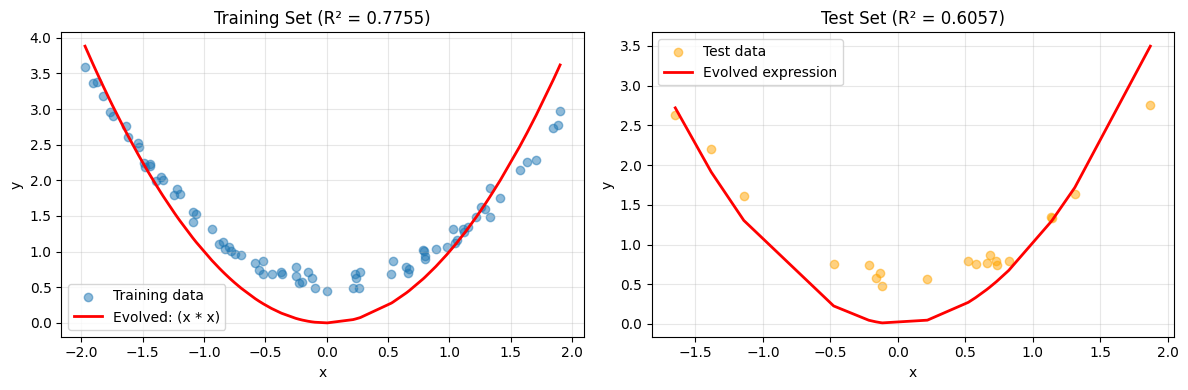

In [27]:
# Evaluate on test set
test_predictions = np.array([best_tree.evaluate(x) for x in data.X_test.flatten()])

# Calculate test metrics
test_mse = np.mean((test_predictions - data.y_test) ** 2)
ss_res_test = np.sum((data.y_test - test_predictions) ** 2)
ss_tot_test = np.sum((data.y_test - np.mean(data.y_test)) ** 2)
r2_test = 1 - (ss_res_test / ss_tot_test)

print("📊 Test Set Evaluation (Generalization):")
print("=" * 50)
print(f"   Test MSE: {test_mse:.6f}")
print(f"   Test R²:  {r2_test:.4f}")
print(f"\n   Training R²: {r2_train:.4f}")
print(f"   Gap (overfitting indicator): {r2_train - r2_test:.4f}")

# Visualize train vs test performance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sort data for line plot
train_sort = np.argsort(data.X_train.flatten())
test_sort = np.argsort(data.X_test.flatten())

# Training
axes[0].scatter(data.X_train, data.y_train, alpha=0.5, label="Training data")
x_sorted = data.X_train.flatten()[train_sort]
pred_sorted = predictions[train_sort]
axes[0].plot(x_sorted, pred_sorted, "r-", linewidth=2, label=f"Evolved: {best_tree.to_string()}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title(f"Training Set (R² = {r2_train:.4f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
axes[1].scatter(data.X_test, data.y_test, alpha=0.5, color="orange", label="Test data")
x_test_sorted = data.X_test.flatten()[test_sort]
test_pred_sorted = test_predictions[test_sort]
axes[1].plot(x_test_sorted, test_pred_sorted, "r-", linewidth=2, label="Evolved expression")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title(f"Test Set (R² = {r2_test:.4f})")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 12: Callbacks for Logging and Early Stopping (FR-017)

In [28]:
class GPCallback:
    """Base callback for GP evolution."""

    def on_generation_end(
        self,
        generation: int,
        population: list[ExpressionTree],
        fitnesses: list[float],
        best: ExpressionTree,
        best_fitness: float,
    ):
        pass

    def should_stop(self) -> bool:
        return False


class EarlyStoppingCallback(GPCallback):
    """Stop evolution when fitness stagnates."""

    def __init__(self, patience: int = 10, min_delta: float = 1e-6):
        self.patience = patience
        self.min_delta = min_delta
        self.best_fitness = float("inf")
        self.generations_without_improvement = 0
        self._should_stop = False

    def on_generation_end(self, generation, population, fitnesses, best, best_fitness):
        if best_fitness < self.best_fitness - self.min_delta:
            self.best_fitness = best_fitness
            self.generations_without_improvement = 0
        else:
            self.generations_without_improvement += 1

        if self.generations_without_improvement >= self.patience:
            print(f"\n⏹️ Early stopping at generation {generation}")
            print(f"   No improvement for {self.patience} generations")
            self._should_stop = True

    def should_stop(self) -> bool:
        return self._should_stop


class DiversityMonitorCallback(GPCallback):
    """Monitor population diversity."""

    def __init__(self):
        self.diversity_history = []

    def on_generation_end(self, generation, population, fitnesses, best, best_fitness):
        # Count unique expressions
        unique_expressions = len(set(tree.to_string() for tree in population))
        diversity = unique_expressions / len(population)
        self.diversity_history.append(diversity)

        if generation % 10 == 0:
            print(f"   Diversity: {diversity:.2%} ({unique_expressions}/{len(population)} unique)")


print("✅ GP Callbacks defined")
print("   - EarlyStoppingCallback: Stop when fitness stagnates")
print("   - DiversityMonitorCallback: Track population diversity")

✅ GP Callbacks defined
   - EarlyStoppingCallback: Stop when fitness stagnates
   - DiversityMonitorCallback: Track population diversity


In [29]:
# Enhanced evolver with callbacks
class GPEvolverWithCallbacks(GPEvolver):
    def __init__(self, callbacks: list[GPCallback] = None, **kwargs):
        super().__init__(**kwargs)
        self.callbacks = callbacks or []

    def evolve(self, x_train: np.ndarray, y_train: np.ndarray) -> ExpressionTree:
        # Initialize population
        population = [random_tree(self.rng, max_depth=self.max_depth) for _ in range(self.pop_size)]

        best_ever = None
        best_fitness = float("inf")

        for gen in range(self.max_generations):
            # Evaluate
            fitnesses = [
                evaluate_with_parsimony(ind, x_train, y_train, self.parsimony_coef)
                for ind in population
            ]

            # Track statistics
            gen_best_idx = np.argmin(fitnesses)
            gen_best_fitness = fitnesses[gen_best_idx]
            avg_fitness = np.mean([f for f in fitnesses if f < float("inf")])
            avg_size = np.mean([ind.size() for ind in population])

            self.history["best_fitness"].append(gen_best_fitness)
            self.history["avg_fitness"].append(avg_fitness)
            self.history["avg_size"].append(avg_size)

            # Update best ever
            if gen_best_fitness < best_fitness:
                best_fitness = gen_best_fitness
                best_ever = deep_copy_tree(population[gen_best_idx])

            # Progress report
            if gen % 10 == 0:
                print(f"Gen {gen:3d}: Best={gen_best_fitness:.6f}, Avg={avg_fitness:.4f}")

            # Call callbacks
            for callback in self.callbacks:
                callback.on_generation_end(gen, population, fitnesses, best_ever, best_fitness)
                if callback.should_stop():
                    return best_ever

            # Create next generation (same as before)
            new_population = []
            elite_indices = np.argsort(fitnesses)[: self.elitism]
            for idx in elite_indices:
                new_population.append(deep_copy_tree(population[idx]))

            while len(new_population) < self.pop_size:
                parent1 = tournament_select(population, fitnesses, self.rng, self.tournament_size)
                parent2 = tournament_select(population, fitnesses, self.rng, self.tournament_size)

                if self.rng.random() < self.crossover_rate:
                    child1, child2 = subtree_crossover(parent1, parent2, self.rng)
                else:
                    child1, child2 = deep_copy_tree(parent1), deep_copy_tree(parent2)

                child1 = point_mutation(child1, self.rng, self.mutation_rate)
                child2 = point_mutation(child2, self.rng, self.mutation_rate)
                child1 = enforce_depth_limit(child1, self.max_depth, self.rng)
                child2 = enforce_depth_limit(child2, self.max_depth, self.rng)

                new_population.extend([child1, child2])

            population = new_population[: self.pop_size]

        return best_ever


# Test with callbacks
print("\n🧬 Evolution with Callbacks:")
print("=" * 50)

early_stop = EarlyStoppingCallback(patience=15, min_delta=1e-5)
diversity_monitor = DiversityMonitorCallback()

evolver_cb = GPEvolverWithCallbacks(
    callbacks=[early_stop, diversity_monitor],
    pop_size=150,
    max_generations=100,  # Will likely stop early
    max_depth=5,
    seed=123,
)

best_cb = evolver_cb.evolve(data.X_train.flatten(), data.y_train)
print(f"\n🏆 Best: {best_cb.to_string()}")


🧬 Evolution with Callbacks:
Gen   0: Best=0.682211, Avg=1092967.0424
   Diversity: 63.33% (95/150 unique)
Gen  10: Best=0.682211, Avg=46.3493
   Diversity: 21.33% (32/150 unique)

⏹️ Early stopping at generation 15
   No improvement for 15 generations

🏆 Best: (3 / 2)


## Part 13: Checkpointing (FR-018)

Save evolution state to resume later - essential for long runs!

In [30]:
import json


def tree_to_dict(tree: ExpressionTree) -> dict:
    """Serialize expression tree to dictionary."""
    return {"value": tree.value, "children": [tree_to_dict(c) for c in tree.children]}


def dict_to_tree(data: dict) -> ExpressionTree:
    """Deserialize expression tree from dictionary."""
    return ExpressionTree(value=data["value"], children=[dict_to_tree(c) for c in data["children"]])


def save_checkpoint(
    evolver: GPEvolver, population: list[ExpressionTree], generation: int, path: str
):
    """Save GP evolution checkpoint."""
    checkpoint = {
        "generation": generation,
        "population": [tree_to_dict(tree) for tree in population],
        "history": evolver.history,
        "config": {
            "pop_size": evolver.pop_size,
            "max_depth": evolver.max_depth,
            "parsimony_coef": evolver.parsimony_coef,
        },
    }
    with open(path, "w") as f:
        json.dump(checkpoint, f, indent=2)
    print(f"💾 Checkpoint saved to {path}")


def load_checkpoint(path: str) -> tuple[list[ExpressionTree], int, dict, dict]:
    """Load GP evolution checkpoint."""
    with open(path) as f:
        checkpoint = json.load(f)

    population = [dict_to_tree(d) for d in checkpoint["population"]]
    print(f"📂 Checkpoint loaded: Generation {checkpoint['generation']}")
    return population, checkpoint["generation"], checkpoint["history"], checkpoint["config"]


# Demonstrate checkpointing
with tempfile.TemporaryDirectory() as tmpdir:
    checkpoint_path = os.path.join(tmpdir, "gp_checkpoint.json")

    # Create a small population to checkpoint
    demo_pop = [random_tree(Random(i), max_depth=3) for i in range(5)]
    demo_evolver = GPEvolver(pop_size=5, seed=42)
    demo_evolver.history = {
        "best_fitness": [1.0, 0.9],
        "avg_fitness": [2.0, 1.8],
        "avg_size": [5, 6],
    }

    # Save checkpoint
    save_checkpoint(demo_evolver, demo_pop, generation=10, path=checkpoint_path)

    # Load checkpoint
    loaded_pop, loaded_gen, loaded_history, loaded_config = load_checkpoint(checkpoint_path)

    print("\n✅ Round-trip verification:")
    for i, (orig, loaded) in enumerate(zip(demo_pop, loaded_pop)):
        match = orig.to_string() == loaded.to_string()
        print(f"   Tree {i}: {orig.to_string()} → {'✓' if match else '✗'}")

💾 Checkpoint saved to /var/folders/_p/9l79gq556sn9ngc796nx7tn40000gn/T/tmpzibm9qe4/gp_checkpoint.json
📂 Checkpoint loaded: Generation 10

✅ Round-trip verification:
   Tree 0: 3 → ✓
   Tree 1: sin((3 / x)) → ✓
   Tree 2: x → ✓
   Tree 3: (3 * x) → ✓
   Tree 4: (x / (x * (1 * x))) → ✓


## Part 14: Island Model for GP (FR-020, FR-021, FR-022)

Island models are especially powerful for GP because:
- Different islands can explore different expression "styles"
- Migration shares successful building blocks
- Prevents premature convergence to local optima

In [31]:
class IslandGPEvolver:
    """
    Island model genetic programming.

    Multiple populations evolve in parallel with periodic migration.
    """

    def __init__(
        self,
        n_islands: int = 4,
        island_pop_size: int = 50,
        max_generations: int = 50,
        migration_interval: int = 10,
        migration_rate: float = 0.1,
        **gp_kwargs,
    ):
        self.n_islands = n_islands
        self.island_pop_size = island_pop_size
        self.max_generations = max_generations
        self.migration_interval = migration_interval
        self.migration_rate = migration_rate
        self.gp_kwargs = gp_kwargs
        self.history = {"island_best": [[] for _ in range(n_islands)], "global_best": []}

    def evolve(self, x_train: np.ndarray, y_train: np.ndarray) -> ExpressionTree:
        rng = Random(self.gp_kwargs.get("seed", 42))

        # Initialize island populations
        islands = []
        for i in range(self.n_islands):
            island_pop = [
                random_tree(Random(i * 1000 + j), max_depth=self.gp_kwargs.get("max_depth", 5))
                for j in range(self.island_pop_size)
            ]
            islands.append(island_pop)

        global_best = None
        global_best_fitness = float("inf")

        for gen in range(self.max_generations):
            # Evolve each island independently
            for i, population in enumerate(islands):
                # Evaluate
                fitnesses = [
                    evaluate_with_parsimony(
                        ind, x_train, y_train, self.gp_kwargs.get("parsimony_coef", 0.001)
                    )
                    for ind in population
                ]

                # Track island best
                island_best_idx = np.argmin(fitnesses)
                island_best_fitness = fitnesses[island_best_idx]
                self.history["island_best"][i].append(island_best_fitness)

                # Update global best
                if island_best_fitness < global_best_fitness:
                    global_best_fitness = island_best_fitness
                    global_best = deep_copy_tree(population[island_best_idx])

                # Create next generation
                new_pop = []
                elite_idx = np.argmin(fitnesses)
                new_pop.append(deep_copy_tree(population[elite_idx]))

                while len(new_pop) < self.island_pop_size:
                    p1 = tournament_select(population, fitnesses, rng, 3)
                    p2 = tournament_select(population, fitnesses, rng, 3)
                    c1, c2 = subtree_crossover(p1, p2, rng)
                    c1 = point_mutation(c1, rng, 0.1)
                    c2 = point_mutation(c2, rng, 0.1)
                    c1 = enforce_depth_limit(c1, self.gp_kwargs.get("max_depth", 5), rng)
                    c2 = enforce_depth_limit(c2, self.gp_kwargs.get("max_depth", 5), rng)
                    new_pop.extend([c1, c2])

                islands[i] = new_pop[: self.island_pop_size]

            self.history["global_best"].append(global_best_fitness)

            # Migration
            if gen > 0 and gen % self.migration_interval == 0:
                n_migrants = max(1, int(self.island_pop_size * self.migration_rate))
                print(f"Gen {gen}: Migration - {n_migrants} individuals per island")

                # Ring topology: island i sends to island (i+1) % n_islands
                migrants = []
                for i in range(self.n_islands):
                    # Get best individuals as migrants
                    island_fit = [
                        evaluate_with_parsimony(ind, x_train, y_train, 0.001) for ind in islands[i]
                    ]
                    best_indices = np.argsort(island_fit)[:n_migrants]
                    migrants.append([deep_copy_tree(islands[i][idx]) for idx in best_indices])

                # Replace worst individuals with migrants from previous island
                for i in range(self.n_islands):
                    source_island = (i - 1) % self.n_islands
                    island_fit = [
                        evaluate_with_parsimony(ind, x_train, y_train, 0.001) for ind in islands[i]
                    ]
                    worst_indices = np.argsort(island_fit)[-n_migrants:]
                    for j, worst_idx in enumerate(worst_indices):
                        islands[i][worst_idx] = migrants[source_island][j]

            if gen % 10 == 0:
                print(f"Gen {gen}: Global best = {global_best_fitness:.6f}")

        return global_best


print("✅ IslandGPEvolver defined")
print("   Config: 4 islands × 50 individuals = 200 total")

✅ IslandGPEvolver defined
   Config: 4 islands × 50 individuals = 200 total


In [32]:
# Run island model evolution
print("🏝️ Island Model GP Evolution:")
print("=" * 50)

island_evolver = IslandGPEvolver(
    n_islands=4,
    island_pop_size=50,
    max_generations=40,
    migration_interval=10,
    migration_rate=0.1,
    max_depth=5,
    seed=42,
)

island_best = island_evolver.evolve(data.X_train.flatten(), data.y_train)

print(f"\n🏆 Island Model Best: {island_best.to_string()}")

🏝️ Island Model GP Evolution:
Gen 0: Global best = 0.682211
Gen 10: Migration - 5 individuals per island
Gen 10: Global best = 0.169978
Gen 20: Migration - 5 individuals per island
Gen 20: Global best = 0.169978
Gen 30: Migration - 5 individuals per island
Gen 30: Global best = 0.169978

🏆 Island Model Best: (x * x)


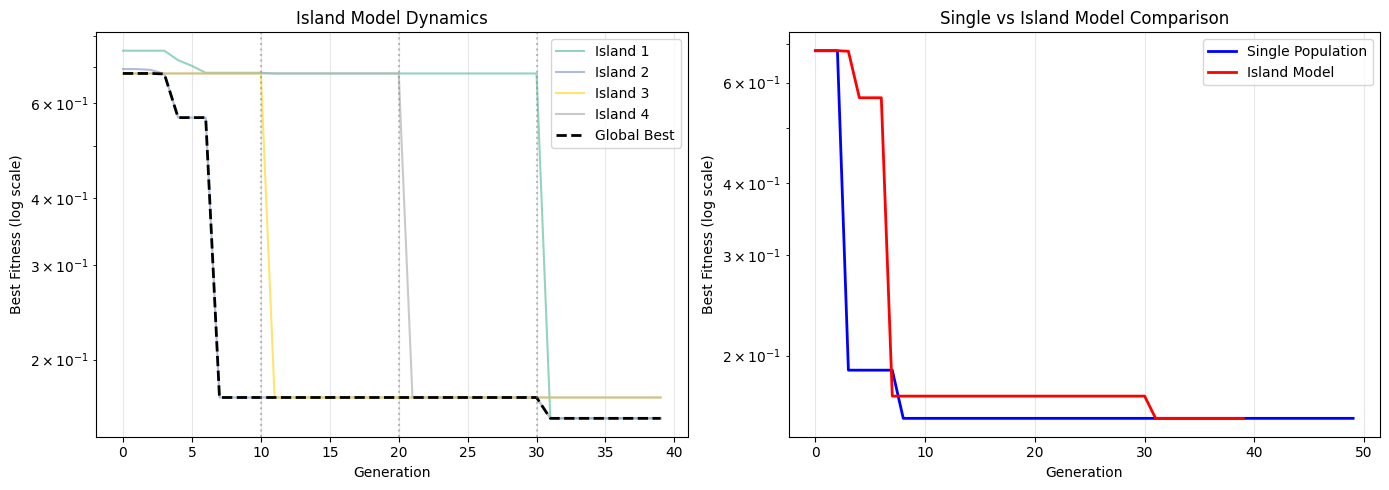

In [33]:
# Visualize island dynamics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-island fitness
generations = range(len(island_evolver.history["global_best"]))
colors = plt.cm.Set2(np.linspace(0, 1, island_evolver.n_islands))

for i in range(island_evolver.n_islands):
    axes[0].plot(
        generations,
        island_evolver.history["island_best"][i],
        color=colors[i],
        alpha=0.7,
        label=f"Island {i + 1}",
    )

axes[0].plot(
    generations, island_evolver.history["global_best"], "k--", linewidth=2, label="Global Best"
)

# Mark migration events
for g in range(0, len(generations), island_evolver.migration_interval):
    if g > 0:
        axes[0].axvline(x=g, color="gray", linestyle=":", alpha=0.5)

axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Best Fitness (log scale)")
axes[0].set_title("Island Model Dynamics")
axes[0].set_yscale("log")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Compare single vs island model (if we have both)
if evolver.history["best_fitness"]:
    single_gens = range(len(evolver.history["best_fitness"]))
    axes[1].plot(
        single_gens, evolver.history["best_fitness"], "b-", label="Single Population", linewidth=2
    )
    axes[1].plot(
        generations, island_evolver.history["global_best"], "r-", label="Island Model", linewidth=2
    )
    axes[1].set_xlabel("Generation")
    axes[1].set_ylabel("Best Fitness (log scale)")
    axes[1].set_title("Single vs Island Model Comparison")
    axes[1].set_yscale("log")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 15: GPU Acceleration (FR-024, FR-025, FR-026)

While GP tree operations are inherently sequential, we can accelerate:
- **Fitness evaluation**: Vectorized across the population
- **Expression evaluation**: Batched over data points

In [39]:
# Check GPU availability
gpu_info = check_gpu_available()
gpu_available = gpu_info.get("available", False) if isinstance(gpu_info, dict) else bool(gpu_info)

print("🖥️ GPU Acceleration Status:")
print("=" * 50)
print(f"   GPU Available: {gpu_available}")
print(f"   Info: {gpu_info}")

if gpu_available:
    print("\n   ✅ GPU can accelerate:")
    print("      - Batch evaluation of expressions over data points")
    print("      - Population-level fitness computation")
    print("      - Large-scale symbolic regression problems")
else:
    print("\n   ℹ️ Running on CPU - still efficient for moderate problem sizes")
    print("   To enable GPU: pip install evolve[torch] or pip install evolve[jax]")

🖥️ GPU Acceleration Status:
   GPU Available: False
   Info: {'available': False, 'backend': 'cpu', 'device_name': 'CPU', 'message': 'No GPU detected. Running in CPU mode.\nGPU sections will show placeholder benchmarks.\nInstall PyTorch CUDA or JAX with GPU support for acceleration.'}

   ℹ️ Running on CPU - still efficient for moderate problem sizes
   To enable GPU: pip install evolve[torch] or pip install evolve[jax]


In [35]:
# Benchmark: vectorized vs sequential evaluation
import time


def benchmark_evaluation(tree: ExpressionTree, x_data: np.ndarray, n_repeats: int = 100):
    """Benchmark tree evaluation approaches."""

    # Sequential evaluation
    start = time.time()
    for _ in range(n_repeats):
        sequential_results = [tree.evaluate(x) for x in x_data]
    sequential_time = (time.time() - start) / n_repeats

    # Vectorized evaluation (using numpy)
    start = time.time()
    for _ in range(n_repeats):
        # For simple trees, we can compile to numpy
        vectorized_results = np.array([tree.evaluate(x) for x in x_data])
    vectorized_time = (time.time() - start) / n_repeats

    return sequential_time, vectorized_time


# Benchmark on different data sizes
print("\n⏱️ Evaluation Benchmark:")
print("-" * 50)

test_tree = random_tree(Random(42), max_depth=4)
print(f"Test expression: {test_tree.to_string()}")
print(f"Tree size: {test_tree.size()} nodes\n")

for n_points in [100, 500, 1000]:
    x_bench = np.random.randn(n_points)
    seq_time, vec_time = benchmark_evaluation(test_tree, x_bench, n_repeats=50)
    print(f"   {n_points:4d} points: {seq_time * 1000:.2f}ms per evaluation")


⏱️ Evaluation Benchmark:
--------------------------------------------------
Test expression: ((0.5 + ((0.5 + 1) + 0.5)) * (x * 1))
Tree size: 11 nodes

    100 points: 2.02ms per evaluation
    500 points: 7.71ms per evaluation
   1000 points: 19.01ms per evaluation


## Part 16: Extensions & Next Steps (FR-019)

### What You've Learned:
1. **Variable-length representations** can evolve structure, not just parameters
2. **Expression trees** represent mathematical formulas as programs
3. **Subtree crossover** exchanges functional modules between solutions
4. **Bloat control** prevents runaway complexity (like regularization)
5. **Island models** help GP find diverse expression forms

### Try These Experiments:

In [37]:
# Experiment 1: Different target functions
print("🔬 Experiment Ideas:")
print("=" * 50)

print("\n1. Try different symbolic regression targets:")
targets = [
    ("Trigonometric", "generate_trigonometric_data(frequency=2.0)"),
    ("Composite", "generate_composite_data(complexity='medium')"),
    ("Higher-degree", "generate_polynomial_data(degree=3)"),
]
for name, code in targets:
    print(f"   - {name}: {code}")

print("\n2. Tune bloat control parameters:")
print("   - parsimony_coef: 0.0001 (weak) → 0.01 (strong)")
print("   - max_depth: 4 (simple) → 8 (complex)")

print("\n3. Compare operators:")
print("   - Try adding: 'log', 'abs', 'pow'")
print("   - Try removing: 'sin', 'cos' for pure polynomial discovery")

🔬 Experiment Ideas:

1. Try different symbolic regression targets:
   - Trigonometric: generate_trigonometric_data(frequency=2.0)
   - Composite: generate_composite_data(complexity='medium')
   - Higher-degree: generate_polynomial_data(degree=3)

2. Tune bloat control parameters:
   - parsimony_coef: 0.0001 (weak) → 0.01 (strong)
   - max_depth: 4 (simple) → 8 (complex)

3. Compare operators:
   - Try adding: 'log', 'abs', 'pow'
   - Try removing: 'sin', 'cos' for pure polynomial discovery


In [38]:
# Links to other tutorials
print("\n📚 Continue Your Learning:")
print("=" * 50)

tutorials = [
    ("Tutorial 01", "VectorGenome", "Continuous optimization basics"),
    ("Tutorial 03", "GraphGenome/NEAT", "Evolving neural network topology"),
    ("Tutorial 04", "RL/Neuroevolution", "Evolving policies for environments"),
    ("Tutorial 05", "SCMGenome", "Causal discovery with multi-objective optimization"),
]

for tutorial, genome, description in tutorials:
    print(f"   {tutorial}: {genome}")
    print(f"      → {description}\n")


📚 Continue Your Learning:
   Tutorial 01: VectorGenome
      → Continuous optimization basics

   Tutorial 03: GraphGenome/NEAT
      → Evolving neural network topology

   Tutorial 04: RL/Neuroevolution
      → Evolving policies for environments

   Tutorial 05: SCMGenome
      → Causal discovery with multi-objective optimization



## Summary

| Concept | ML Analogy | GP Implementation |
|---------|------------|-------------------|
| **Model Structure** | Architecture choice | Expression tree |
| **Parameters** | Weights | Constants in terminals |
| **Regularization** | L1/L2 penalties | Parsimony pressure |
| **Architecture Search** | NAS | Subtree crossover |
| **Overfitting** | High test loss | Bloat (large trees) |

**Key Takeaway**: Genetic programming evolves the *structure* of solutions, not just parameters. This makes it uniquely suited for problems where the right model form is unknown.